# El poder de las redes sociales en elecciones locales
## Análisis exploratorio maestro — de la evidencia binaria a la selección de variables

La historia avanza en **cuatro actos** que escalan en rigor:

| Acto | Pregunta | Cierre |
|------|----------|--------|
| **1** | ¿Importan las redes para ganar? | Los ganadores reciben más interacciones (absoluto y relativo) |
| **2** | ¿El líder digital es el ganador? | La dominancia acierta muy por encima del azar |
| **3** | ¿La relación es solo binaria o de grado? | La cuota digital predice la cuota de voto (corrigiendo el artefacto composicional) |
| **4** | ¿Cuál señal digital sirve de verdad? | Matriz de R²: qué lente × tipo × plataforma aporta más |

Cada métrica se mira bajo **cuatro lentes**: **Totales** (volumen) · **Dominancia** (cuota de la contienda) ·
**Por publicación** (interacciones / nº de posts) · **Por publicación y seguidor** ((I/posts)/seguidores).

> Objetivo a predecir: **cuota de voto dentro del campo competitivo**, en escala logit → modelo *elección-agnóstico*.


---
# Acto 0 — Datos

Cada fila de `df_completo` es una **publicación**, con todos los atributos del candidato
(interacciones por tipo, seguidores por plataforma) y de su municipio.


In [1]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu, binomtest
from scipy.special import logit as _logit
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline

AZUL_SABANA = "#1A2F6F"     # identidad institucional RGB(26,47,111)
ROJO        = "#FF4B4B"
GRIS        = "#A9A9A9"


In [2]:
# ---- Rutas ----
base_path       = os.getcwd()
resultados_path = os.path.join(base_path, "resultados")
excel_path      = os.path.join(os.path.dirname(base_path), "Colombia", "Resultados electorales.xlsx")
csv_unificado   = os.path.join(resultados_path, "redes_unificadas_descontadas.csv")
csv_seguidores  = os.path.join(resultados_path, "seguidores.csv")

df_redes      = pd.read_csv(csv_unificado, sep=";", encoding="utf-8-sig")
df_electoral  = pd.read_excel(excel_path, sheet_name="Candidatos E-26 ALC").rename(columns={"ID Candidato": "id_candidato"})
df_poblacion  = pd.read_excel(excel_path, sheet_name="Población 2023 (DANE)")
df_seguidores = pd.read_csv(csv_seguidores, sep=";", encoding="utf-8-sig").fillna(0)

# Exclusiones: Piedecuesta (68547) y Barrancabermeja (68081) -> ganadores sin redes activas
df_redes = df_redes[~df_redes["id_candidato"].str.contains("68547", na=False)]
df_redes = df_redes[~df_redes["id_candidato"].str.contains("68081", na=False)]
print(f"Publicaciones: {len(df_redes)} | Plataformas: {sorted(df_redes['red_social'].unique())}")


Publicaciones: 8684 | Plataformas: ['Facebook', 'TikTok', 'Twitter']


In [3]:
# ---- Merge: redes + seguidores + electoral + población ----
df_completo = df_redes.merge(
    df_seguidores[["id_candidato", "tiktok_followers", "twitter_followers", "facebook_followers"]],
    on="id_candidato", how="left")
df_completo = df_completo.merge(
    df_electoral[["id_candidato", "Candidato", "Ganador", "Votos"]],
    on="id_candidato", how="left")
df_completo["DIVIPOLA"] = df_completo["id_candidato"].astype(str).str.split("-").str[1].str.zfill(5)

df_poblacion["DIVIPOLA"] = (pd.to_numeric(df_poblacion["DIVIPOLA"], errors="coerce")
                            .fillna(0).astype(int).astype(str).str.zfill(5))
df_completo = df_completo.merge(df_poblacion[["DIVIPOLA", "Municipio", "Población 2023"]],
                                on="DIVIPOLA", how="left")

TIPOS_TODOS = ["likes", "comentarios", "compartidos", "favoritos",
               "fb_haha", "fb_care", "fb_wow", "fb_sad", "fb_angry"]
cols_presentes = [c for c in TIPOS_TODOS if c in df_completo.columns]
df_completo["interacciones_totales"] = df_completo[cols_presentes].sum(axis=1)

print(f"Candidatos: {df_completo['id_candidato'].nunique()} | Municipios: {df_completo['DIVIPOLA'].nunique()}")
print(f"Tipos presentes: {cols_presentes}")


Candidatos: 120 | Municipios: 31
Tipos presentes: ['likes', 'comentarios', 'compartidos', 'favoritos', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']


### Funciones auxiliares

`prepare_lens_data` es el núcleo: dado (tipo, **lente**, plataforma) devuelve por candidato su
valor de lente y su **cuota %** en la contienda. Todo lo demás consume esa salida.


In [4]:
PLATAFORMAS  = ["Facebook", "Twitter", "TikTok"]
FOLLOWER_COL = {"Facebook": "facebook_followers", "Twitter": "twitter_followers", "TikTok": "tiktok_followers"}
LENTES = ["totales", "dominancia", "por_post", "por_post_seg"]
LENTE_LABEL = {"totales": "Totales (volumen)", "dominancia": "Dominancia (% contienda)",
               "por_post": "Por publicación", "por_post_seg": "Por publicación y seguidor"}

def prepare_lens_data(df, metric_col, lente="dominancia", platform=None):
    '''Devuelve por candidato: valor_lente, pct_metric (cuota %), pct_votos, etc.'''
    data = df.copy()
    if platform is not None:
        data = data[data["red_social"] == platform]
    if len(data) == 0 or metric_col not in data.columns:
        return pd.DataFrame()
    if platform is not None:
        data = data.assign(_seg=data[FOLLOWER_COL[platform]])
    else:
        data = data.assign(_seg=data[list(FOLLOWER_COL.values())].sum(axis=1))

    agg = data.groupby(["DIVIPOLA", "id_candidato", "Candidato", "Ganador"]).agg(
        metric_sum=(metric_col, "sum"), n_posts=(metric_col, "count"),
        votos=("Votos", "first"), seguidores=("_seg", "first")).reset_index()

    if lente in ("totales", "dominancia"):
        agg["valor_lente"] = agg["metric_sum"]
    elif lente == "por_post":
        agg["valor_lente"] = agg["metric_sum"] / agg["n_posts"].replace(0, np.nan)
    elif lente == "por_post_seg":
        agg["valor_lente"] = agg["metric_sum"] / (agg["n_posts"].replace(0, np.nan) * agg["seguidores"].replace(0, np.nan))
    else:
        raise ValueError(lente)

    agg = agg.replace([np.inf, -np.inf], np.nan)
    agg["pct_metric"] = (agg["valor_lente"] / agg.groupby("DIVIPOLA")["valor_lente"].transform("sum")) * 100
    agg["pct_votos"]  = (agg["votos"] / agg.groupby("DIVIPOLA")["votos"].transform("sum")) * 100
    agg = agg.replace([np.inf, -np.inf], np.nan)
    agg = agg[agg.groupby("DIVIPOLA")["valor_lente"].transform("sum") > 0]
    return agg


def r2_decomposition(d, x="pct_metric", y="pct_votos", g="DIVIPOLA"):
    v = d.dropna(subset=[x, y]).copy()
    if len(v) < 3: return np.nan, np.nan, np.nan
    r2_pool = np.corrcoef(v[x], v[y])[0, 1] ** 2
    v["xc"] = v[x] - v.groupby(g)[x].transform("mean")
    v["yc"] = v[y] - v.groupby(g)[y].transform("mean")
    r2_w = np.nan if v["xc"].std() < 1e-10 or v["yc"].std() < 1e-10 else np.corrcoef(v["xc"], v["yc"])[0, 1] ** 2
    m = v.groupby(g)[[x, y]].mean()
    r2_b = np.nan if len(m) < 3 or m[x].std() < 1e-10 else np.corrcoef(m[x], m[y])[0, 1] ** 2
    return r2_pool, r2_w, r2_b


def r2_within_logit(d, x="pct_metric", y="pct_votos", g="DIVIPOLA", eps=1e-3):
    v = d.dropna(subset=[x, y]).copy()
    if len(v) < 3: return np.nan
    v["xl"] = _logit(v[x].clip(eps, 100 - eps) / 100)
    v["yl"] = _logit(v[y].clip(eps, 100 - eps) / 100)
    v["xc"] = v["xl"] - v.groupby(g)["xl"].transform("mean")
    v["yc"] = v["yl"] - v.groupby(g)["yl"].transform("mean")
    if v["xc"].std() < 1e-10 or v["yc"].std() < 1e-10: return np.nan
    return np.corrcoef(v["xc"], v["yc"])[0, 1] ** 2


def ols_fe(d, x="pct_metric", y="pct_votos", g="DIVIPOLA"):
    v = d.dropna(subset=[x, y]).copy(); v[g] = v[g].astype(str)
    if len(v) < 5 or v[x].std() < 1e-10: return np.nan, np.nan
    try:
        m = smf.ols(f"{y} ~ {x} + C({g})", data=v).fit(cov_type="cluster", cov_kwds={"groups": v[g]})
        return m.params[x], m.pvalues[x]
    except Exception:
        return np.nan, np.nan


def mann_whitney_full(d, col, ganador="Ganador"):
    '''Devuelve (p, mediana_ganadores, mediana_no, direccion). '''
    g  = d[d[ganador] == "Sí"][col].dropna()
    ng = d[d[ganador] == "No"][col].dropna()
    if len(g) < 2 or len(ng) < 2: return np.nan, np.nan, np.nan, "-"
    p = mannwhitneyu(g, ng, alternative="two-sided")[1]
    dirn = "Ganadores >" if g.median() > ng.median() else "Ganadores <"
    return p, g.median(), ng.median(), dirn


def acierto_lider(d, col="pct_metric", ganador="Ganador", g="DIVIPOLA"):
    d = d.dropna(subset=[col])
    if len(d) == 0: return dict(aciertos=np.nan, n=0, tasa=np.nan, azar=np.nan, p=np.nan)
    lideres = d.loc[d.groupby(g)[col].idxmax()]
    n = len(lideres); aciertos = int((lideres[ganador] == "Sí").sum())
    k = d.groupby(g).size(); azar = (1 / k).mean()
    p = binomtest(aciertos, n, azar, alternative="greater").pvalue if n else np.nan
    return dict(aciertos=aciertos, n=n, tasa=100*aciertos/n if n else np.nan, azar=100*azar, p=p)

print("Funciones cargadas.")


Funciones cargadas.


---
# Acto 1 — ¿Importan las redes para ganar?

¿Hay relación entre cuántas interacciones recibe un candidato y su éxito electoral?


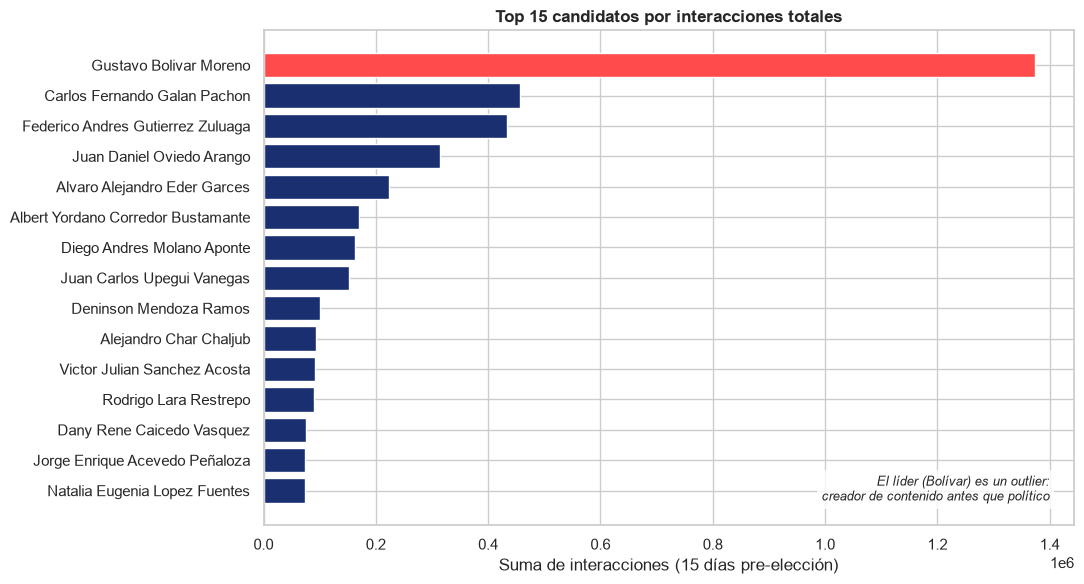

In [5]:
# --- Top 15 candidatos por interacciones totales (Bolívar como outlier) ---
top = df_completo.groupby("Candidato")["interacciones_totales"].sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(11, 6))
colores = [ROJO if i == 0 else AZUL_SABANA for i in range(len(top))]
ax.barh(top.index[::-1], top.values[::-1], color=colores[::-1])
ax.set_title("Top 15 candidatos por interacciones totales", fontweight="bold")
ax.set_xlabel("Suma de interacciones (15 días pre-elección)")
ax.text(0.97, 0.05, "El líder (Bolívar) es un outlier:\ncreador de contenido antes que político",
        transform=ax.transAxes, ha="right", fontsize=9, style="italic",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout(); plt.show()


**Top candidatos desglosado por red social** (de dónde viene cada interacción).

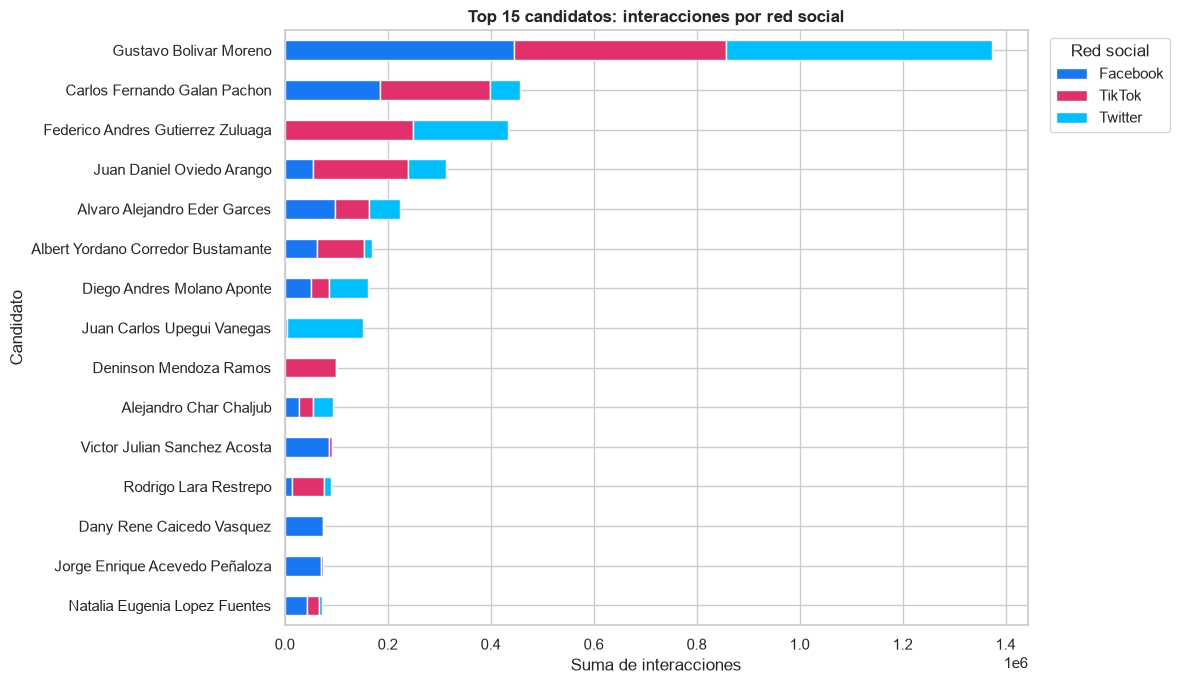

In [6]:
# --- Top 15 por red social (apilado) [portado de 01] ---
top_nombres = df_completo.groupby("Candidato")["interacciones_totales"].sum().sort_values(ascending=False).head(15).index
gd = (df_completo[df_completo["Candidato"].isin(top_nombres)]
      .groupby(["Candidato", "red_social"])["interacciones_totales"].sum().unstack().fillna(0)
      .loc[top_nombres])
ax = gd.plot(kind="barh", stacked=True, figsize=(12, 7),
             color={"Facebook": "#1877F2", "Twitter": "#00BFFF", "TikTok": "#E1306C"})
ax.set_title("Top 15 candidatos: interacciones por red social", fontweight="bold")
ax.set_xlabel("Suma de interacciones"); ax.invert_yaxis()
ax.legend(title="Red social", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


**Desglose por ciudad** (cada panel = un municipio; el ganador en negrilla).

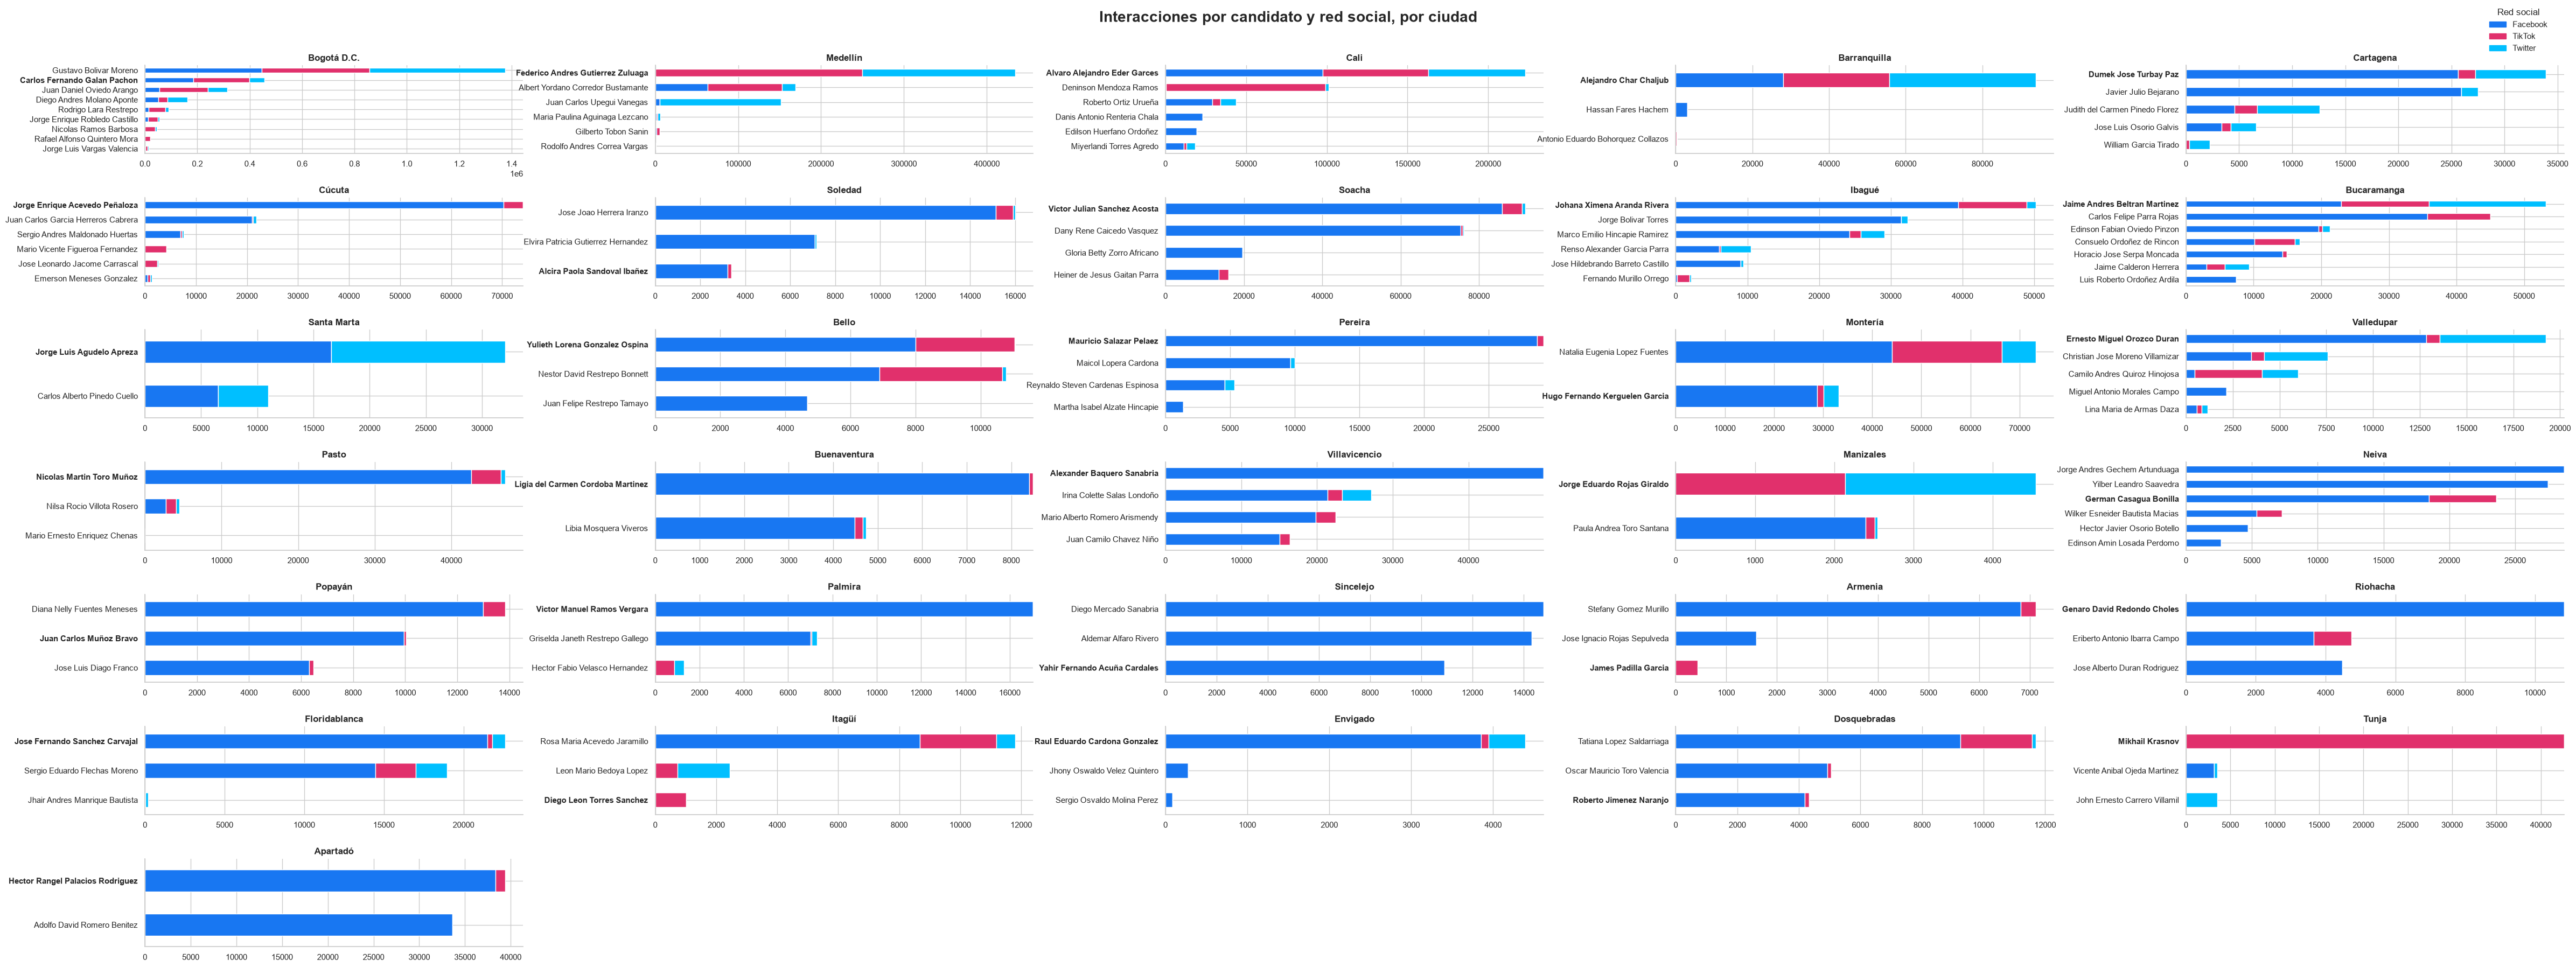

In [7]:
# --- Small multiples: interacciones por candidato y red social, por ciudad [portado de 01] ---
colores_redes = {"Facebook": "#1877F2", "TikTok": "#E1306C", "Twitter": "#00BFFF"}
ciudades = (df_completo[["DIVIPOLA", "Municipio", "Población 2023"]]
            .drop_duplicates().sort_values("Población 2023", ascending=False))
ncols = 5; nrows = math.ceil(len(ciudades) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(48, 2.6 * nrows)); axes = axes.flatten()
for idx, ax in enumerate(axes):
    if idx >= len(ciudades):
        ax.set_visible(False); continue
    row = ciudades.iloc[idx]
    dc = df_completo[df_completo["DIVIPOLA"] == row["DIVIPOLA"]]
    orden = dc.groupby("Candidato")["interacciones_totales"].sum().sort_values(ascending=False).index
    gd = dc.groupby(["Candidato", "red_social"])["interacciones_totales"].sum().unstack().fillna(0).reindex(orden)
    gd.plot(kind="barh", stacked=True, ax=ax, legend=False,
            color=[colores_redes.get(c, "#333") for c in gd.columns])
    ax.set_title(row["Municipio"], fontsize=12, fontweight="bold"); ax.set_ylabel(""); ax.set_xlabel("")
    ax.invert_yaxis(); ax.spines[["top", "right"]].set_visible(False)
    for lab in ax.get_yticklabels():
        w = dc[dc["Candidato"] == lab.get_text()]["Ganador"].values
        if len(w) and str(w[0]).strip().lower() in ("sí", "si", "1", "true"):
            lab.set_fontweight("bold")
fig.suptitle("Interacciones por candidato y red social, por ciudad", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97]); fig.subplots_adjust(wspace=0.35, hspace=0.5)
handles = [Patch(color=c, label=r) for r, c in colores_redes.items()]
fig.legend(handles=handles, title="Red social", loc="upper right", bbox_to_anchor=(0.99, 0.99), frameon=False)
plt.show()


### Distribución ganadores vs no ganadores — las cuatro lentes

Para cada lente comparamos la distribución de ganadores vs no ganadores. *Totales* en escala
log (volumen); las otras tres como cuota % de la contienda.


C:\Users\juansoag\AppData\Local\Temp\ipykernel_8336\445625073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="Ganador", y=col, ax=ax, palette={"Sí": ROJO, "No": GRIS}, order=["No", "Sí"])
C:\Users\juansoag\AppData\Local\Temp\ipykernel_8336\445625073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="Ganador", y=col, ax=ax, palette={"Sí": ROJO, "No": GRIS}, order=["No", "Sí"])
C:\Users\juansoag\AppData\Local\Temp\ipykernel_8336\445625073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="Ganador", y=col,

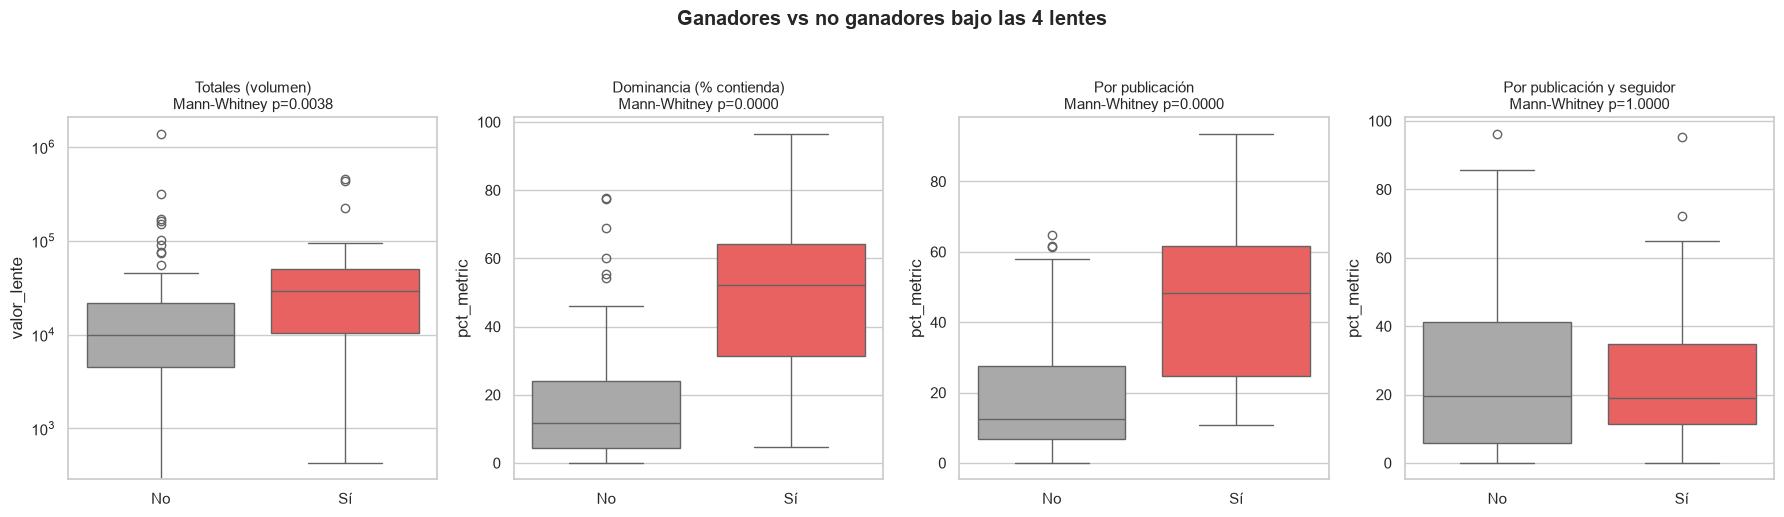

In [8]:
# --- Boxplot ganadores vs no, las 4 LENTES ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, lente in zip(axes, LENTES):
    d = prepare_lens_data(df_completo, "interacciones_totales", lente, None)
    col = "valor_lente" if lente == "totales" else "pct_metric"
    sns.boxplot(data=d, x="Ganador", y=col, ax=ax, palette={"Sí": ROJO, "No": GRIS}, order=["No", "Sí"])
    if lente == "totales":
        ax.set_yscale("log")
    p, *_ = mann_whitney_full(d, col)
    ax.set_title(f"{LENTE_LABEL[lente]}\nMann-Whitney p={p:.4f}" if not np.isnan(p) else LENTE_LABEL[lente],
                 fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel(col)
fig.suptitle("Ganadores vs no ganadores bajo las 4 lentes", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()


### Prueba de diferencia (Mann–Whitney) con conclusión

La tabla ahora dice explícitamente si la diferencia es significativa y en qué dirección.


In [9]:
# --- Tabla Mann-Whitney con CONCLUSIÓN embebida ---
ALPHA = 0.05
filas = []
for lente in LENTES:
    d = prepare_lens_data(df_completo, "interacciones_totales", lente, None)
    col = "valor_lente" if lente == "totales" else "pct_metric"
    p, med_g, med_ng, dirn = mann_whitney_full(d, col)
    filas.append({
        "lente": LENTE_LABEL[lente],
        "mediana_ganadores": round(med_g, 2) if pd.notna(med_g) else np.nan,
        "mediana_no_gan": round(med_ng, 2) if pd.notna(med_ng) else np.nan,
        "p_value": f"{p:.2e}" if pd.notna(p) and p < 0.001 else (f"{p:.4f}" if pd.notna(p) else "-"),
        "conclusión": ("✓ Significativa — " + dirn) if (pd.notna(p) and p < ALPHA) else "✗ No significativa",
        "n": len(d),
    })
tabla_mw = pd.DataFrame(filas)
print(f"Prueba de diferencia ganadores vs no ganadores (α = {ALPHA}):")
tabla_mw


Prueba de diferencia ganadores vs no ganadores (α = 0.05):


,lente,mediana_ganadores,mediana_no_gan,p_value,conclusión,n
0,Totales (volumen),29238.00,9996.00,0.0038,✓ Significativa — Ganadores >,120
1,Dominancia (% contienda),52.06,11.60,8.94e-09,✓ Significativa — Ganadores >,120
2,Por publicación,48.41,12.42,5.21e-08,✓ Significativa — Ganadores >,120
3,Por publicación y seguidor,19.03,19.56,1.0000,✗ No significativa,120


### Gráfico de divulgación — *El poder de las redes sociales en elecciones locales*

Cada fila es una ciudad; la barra (0–100%) se divide en segmentos por candidato según su % de
interacciones. El **ganador va en rojo**; cada segmento lleva el nombre del candidato.


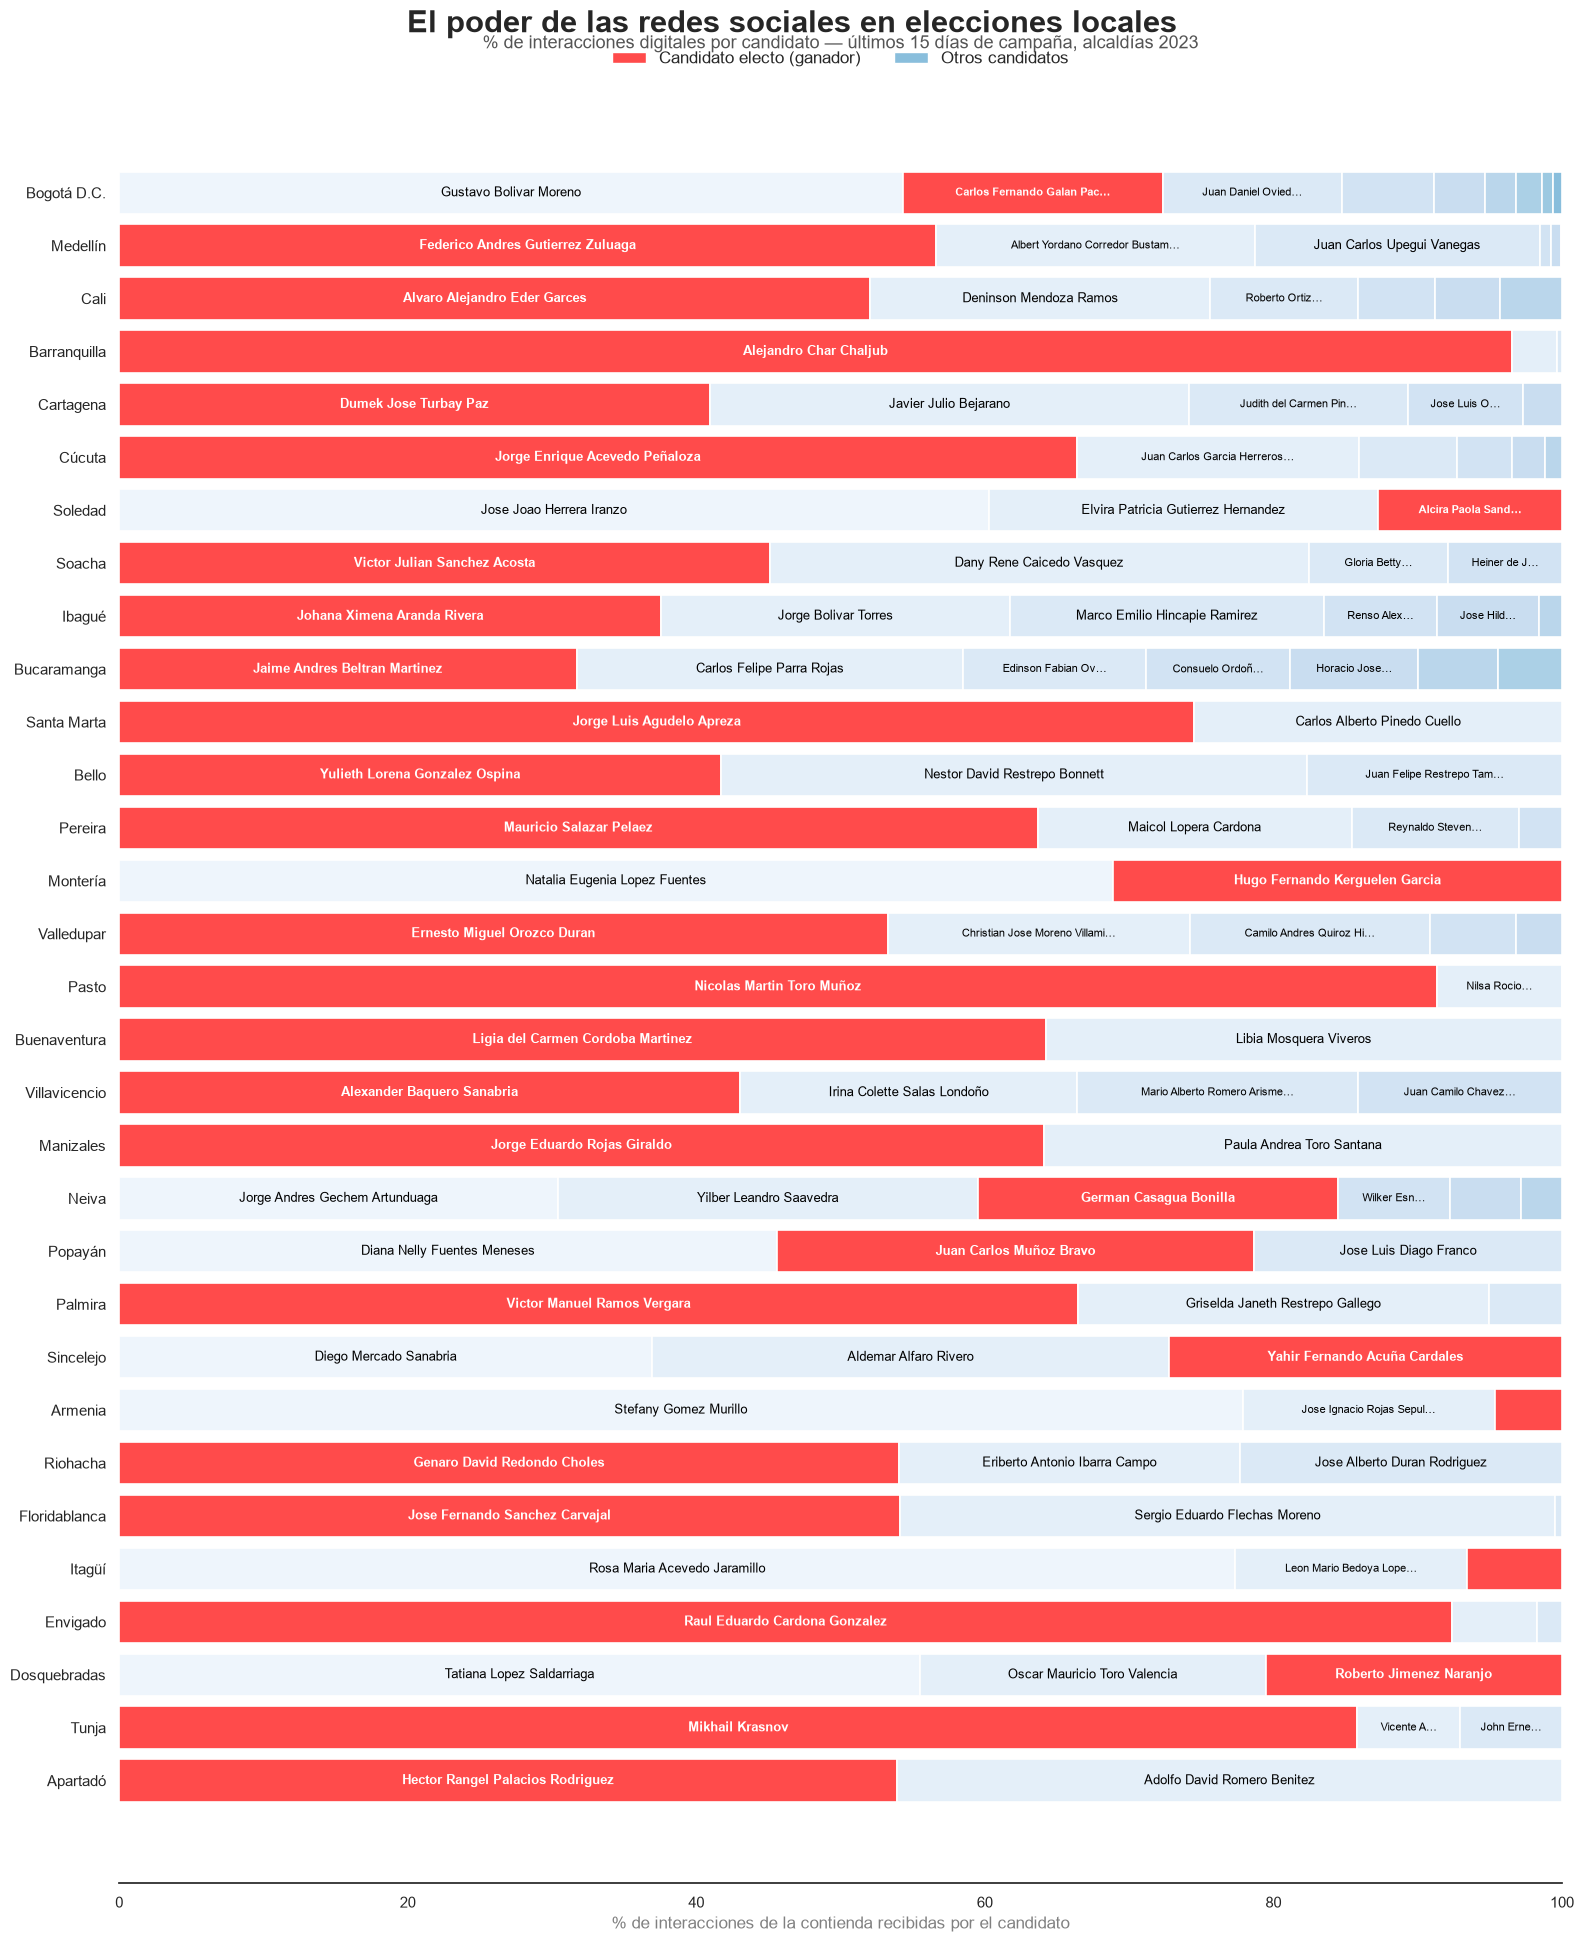

In [10]:
# --- Mapa de dominancia tipo LinkedIn [portado de 01, corregido] ---
dms = df_completo.groupby(["DIVIPOLA", "Municipio", "Candidato", "Ganador"])["interacciones_totales"].sum().reset_index()
dms["porcentaje"] = (dms["interacciones_totales"] / dms.groupby("DIVIPOLA")["interacciones_totales"].transform("sum")) * 100
ranking = (dms[["DIVIPOLA", "Municipio"]].drop_duplicates()
           .merge(df_completo[["DIVIPOLA", "Población 2023"]].drop_duplicates(), on="DIVIPOLA")
           .sort_values("Población 2023", ascending=False))

with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(16, 20))
    paleta = sns.color_palette("Blues", n_colors=20)
    for i, (_, rp) in enumerate(ranking.iterrows()):
        dm = dms[dms["DIVIPOLA"] == rp["DIVIPOLA"]].sort_values("porcentaje", ascending=False).reset_index(drop=True)
        left = 0
        for j, r in dm.iterrows():
            es_gan = r["Ganador"] == "Sí"
            ax.barh(rp["Municipio"], r["porcentaje"], left=left,
                    color=ROJO if es_gan else paleta[j % 20], edgecolor="white", linewidth=1.2)
            if r["porcentaje"] > 7:
                nom = str(r["Candidato"]); mx = int(r["porcentaje"] * 1.4)
                txt = nom if len(nom) <= mx else nom[:mx].strip() + "…"
                ax.text(left + r["porcentaje"]/2, i, txt, va="center", ha="center",
                        color="white" if es_gan else "black",
                        fontsize=8 if len(nom) > mx else 9, weight="bold" if es_gan else "normal")
            left += r["porcentaje"]
    ax.set_xlim(0, 100); ax.invert_yaxis(); ax.spines[["top", "right", "left"]].set_visible(False)
    ax.legend(handles=[Patch(facecolor=ROJO, label="Candidato electo (ganador)"),
                       Patch(facecolor=paleta[8], label="Otros candidatos")],
              loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=2, frameon=False, fontsize=12)
    plt.suptitle("El poder de las redes sociales en elecciones locales", fontsize=22, fontweight="bold", y=0.97)
    ax.set_title("% de interacciones digitales por candidato — últimos 15 días de campaña, alcaldías 2023",
                 fontsize=13, color="#555", pad=30)
    ax.set_xlabel("% de interacciones de la contienda recibidas por el candidato", color="gray")
    plt.tight_layout(); plt.subplots_adjust(top=0.93); plt.show()
sns.set_theme(style="whitegrid")


> **Cierre Acto 1.** Los ganadores reciben más interacciones que los perdedores, en volumen y
> en cuota relativa, y la prueba de diferencia lo confirma para las lentes principales.

---
# Acto 2 — ¿El líder digital es el ganador?

Clasificador winner-take-all ingenuo: ¿el #1 en redes gana? Su acierto es el *baseline de nowcasting*.

> ⚠️ **No confundir:** **dominancia** = cuota continua (alimenta el R²); **acierto del líder** =
> exactitud de la regla "el líder gana" (un sí/no sobre la cima).


In [11]:
# --- Acierto del líder vs azar, sobre las 4 lentes ---
filas = []
for lente in LENTES:
    d = prepare_lens_data(df_completo, "interacciones_totales", lente, None)
    r = acierto_lider(d, "pct_metric")
    filas.append({"lente": LENTE_LABEL[lente], "acierto": f"{r['aciertos']}/{r['n']} ({r['tasa']:.0f}%)",
                  "tasa": round(r["tasa"], 1), "azar_%": round(r["azar"], 1),
                  "p_vs_azar": f"{r['p']:.2e}" if pd.notna(r['p']) and r['p'] < 0.001 else round(r['p'], 4),
                  "supera_azar": "✓" if (pd.notna(r["p"]) and r["p"] < 0.05) else "✗"})
tabla_acierto = pd.DataFrame(filas)
tabla_acierto


,lente,acierto,tasa,azar_%,p_vs_azar,supera_azar
0,Totales (volumen),22/31 (71%),71.0,30.3,3.74e-06,✓
1,Dominancia (% contienda),22/31 (71%),71.0,30.3,3.74e-06,✓
2,Por publicación,18/31 (58%),58.1,30.3,0.0012,✓
3,Por publicación y seguidor,6/31 (19%),19.4,30.3,0.942,✗


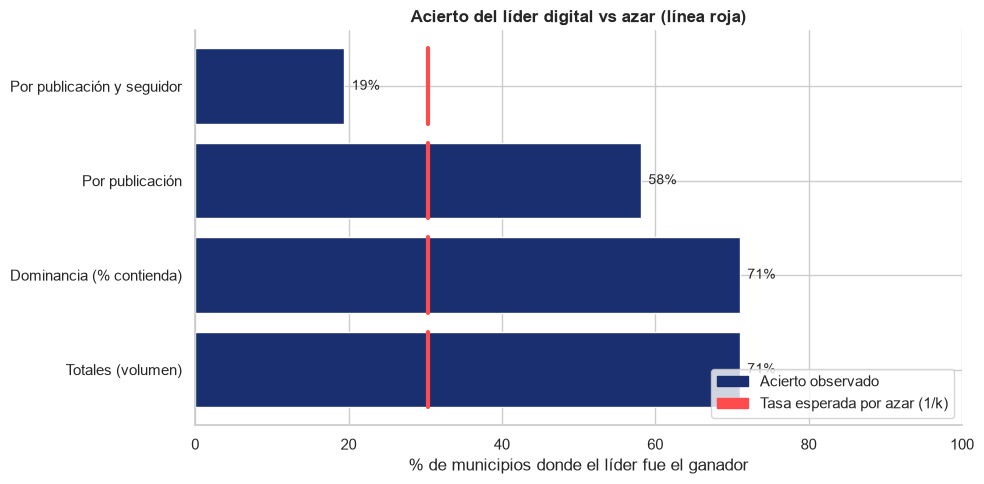

In [12]:
# --- Visualización: acierto del líder vs azar por lente ---
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(tabla_acierto))
ax.barh(y, tabla_acierto["tasa"], color=AZUL_SABANA, label="Acierto observado")
for yi, (t, az) in enumerate(zip(tabla_acierto["tasa"], tabla_acierto["azar_%"])):
    ax.plot([az, az], [yi - 0.4, yi + 0.4], color=ROJO, lw=3)
    ax.text(t + 1, yi, f"{t:.0f}%", va="center", fontsize=10)
ax.set_yticks(y); ax.set_yticklabels(tabla_acierto["lente"]); ax.set_xlim(0, 100)
ax.set_xlabel("% de municipios donde el líder fue el ganador")
ax.set_title("Acierto del líder digital vs azar (línea roja)", fontweight="bold")
ax.legend(handles=[Patch(color=AZUL_SABANA, label="Acierto observado"),
                   Patch(color=ROJO, label="Tasa esperada por azar (1/k)")], loc="lower right")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()


> **Cierre Acto 2.** El líder en dominancia acierta muy por encima del azar (que con k>2
> candidatos es ~1/k, no 50%). Baseline ingenuo sorprendentemente fuerte.

---
# Acto 3 — De lo binario a lo continuo

Pasamos de "ganó / no ganó" a predecir el **grado**: la cuota de voto. Aquí aparece el scatter
y el **artefacto composicional** que hay que corregir.


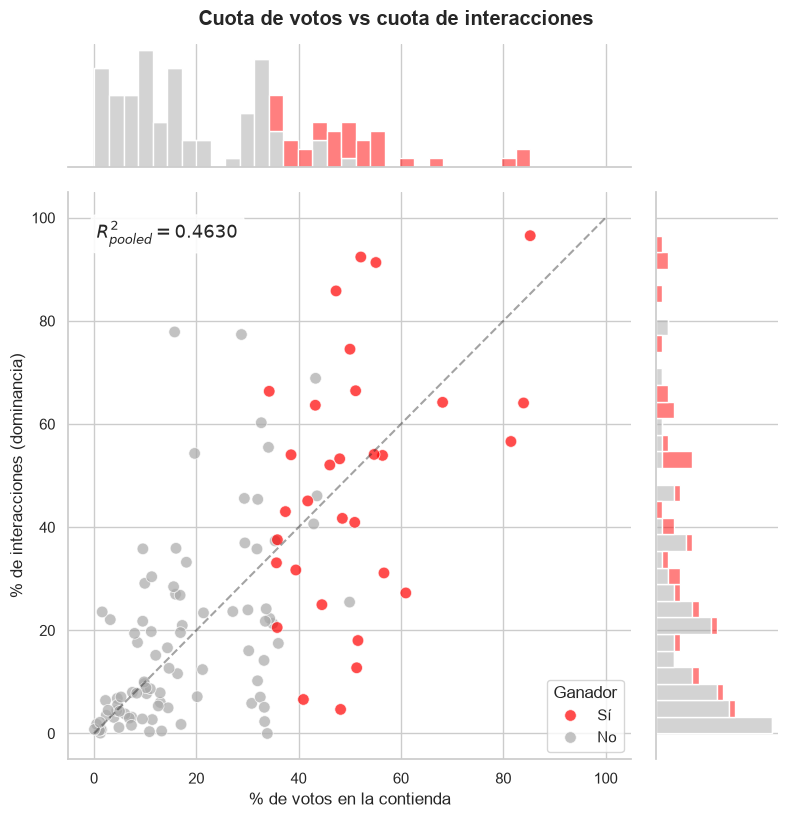

In [13]:
# --- Scatter % votos vs % interacciones (dominancia, cross-platform) ---
d = prepare_lens_data(df_completo, "interacciones_totales", "dominancia", None)
r2_p, r2_w, r2_b = r2_decomposition(d)
g = sns.JointGrid(data=d, x="pct_votos", y="pct_metric", hue="Ganador",
                  palette={"Sí": "#FF0000", "No": GRIS}, height=8, ratio=4)
g.plot_joint(sns.scatterplot, s=70, alpha=0.7)
g.plot_marginals(sns.histplot, bins=30, multiple="stack", alpha=0.5)
g.ax_joint.plot([0, 100], [0, 100], "k--", alpha=0.4)
g.ax_joint.text(0.05, 0.95, f"$R^2_{{pooled}}={r2_p:.4f}$", transform=g.ax_joint.transAxes,
                fontsize=13, va="top", bbox=dict(boxstyle="round", fc="white", alpha=0.9))
g.ax_joint.set_xlabel("% de votos en la contienda"); g.ax_joint.set_ylabel("% de interacciones (dominancia)")
g.fig.suptitle("Cuota de votos vs cuota de interacciones", fontweight="bold", y=1.02); plt.show()


In [14]:
# --- Descomposición del R² ---
print(f"R² pooled  (lo que se ve)             : {r2_p:.4f}")
print(f"R² within  (SEÑAL HONESTA, controla k): {r2_w:.4f}")
print(f"R² between (artefacto puro de k)      : {r2_b:.4f}")
print(f"\nBrecha pooled - within = {r2_p - r2_w:+.4f}  -> inflado mecánico por mezclar municipios de distinto tamaño")


R² pooled  (lo que se ve)             : 0.4630
R² within  (SEÑAL HONESTA, controla k): 0.3360
R² between (artefacto puro de k)      : 1.0000

Brecha pooled - within = +0.1270  -> inflado mecánico por mezclar municipios de distinto tamaño


**Por qué importa.** Las cuotas suman 100% dentro de cada municipio, así que la media de cada
eje es `100/k`: las medias municipales caen sobre y=x por aritmética (R² between ≈ 1, sin
información). El **R² within** es el único estimador honesto y es el que usamos en el Acto 4.

> **Cierre Acto 3.** La cuota digital predice la cuota de voto; se reporta el *within*, no el pooled.

---
# Acto 4 — El motor: ¿cuál señal digital sirve de verdad?

Cruzamos **lente** (dominancia · por publicación · por publicación y seguidor) × **tipo**
(likes · comentarios · compartidos) × **plataforma** (cross · FB · Twitter · TikTok). Para cada
celda: binario (acierto vs azar) y continuo (R²_within, R²_within_logit, coef clusterizado).


In [15]:
# --- Grid de variantes ---
LENTES_GRID = ["dominancia", "por_post", "por_post_seg"]
TIPOS = ["likes", "comentarios", "compartidos"]
PLATS = [None, "Facebook", "Twitter", "TikTok"]
variantes = []
for lente in LENTES_GRID:
    variantes.append(dict(nombre=f"TOTAL · {lente}", tipo="interacciones_totales", lente=lente, plat=None,
                          familia=f"{lente} | cross"))
for lente in LENTES_GRID:
    for tipo in TIPOS:
        for plat in PLATS:
            variantes.append(dict(nombre=f"{tipo} · {lente} · {plat or 'cross'}", tipo=tipo, lente=lente,
                                  plat=plat, familia=f"{lente} | {'cross' if plat is None else plat}"))
print(f"Variantes: {len(variantes)}")


Variantes: 39


In [16]:
# --- Ejecución del motor ---
res = []
for v in variantes:
    d = prepare_lens_data(df_completo, v["tipo"], v["lente"], v["plat"])
    if len(d) < 5: continue
    r2_p, r2_w, r2_b = r2_decomposition(d)
    coef, p_fe = ols_fe(d)
    a = acierto_lider(d, "pct_metric")
    p_mw, *_ = mann_whitney_full(d, "pct_metric")
    res.append({"variante": v["nombre"], "familia": v["familia"], "lente": v["lente"], "tipo": v["tipo"],
                "plataforma": v["plat"] or "cross", "R2_pooled": r2_p, "R2_within": r2_w,
                "R2_within_logit": r2_within_logit(d), "coef_FE": coef, "p_FE": p_fe,
                "acierto_%": round(a["tasa"], 1), "azar_%": round(a["azar"], 1), "p_acierto": a["p"],
                "p_MW": p_mw, "n": len(d), "n_munis": d["DIVIPOLA"].nunique()})
df_motor = pd.DataFrame(res)
df_motor["p_FDR"] = np.nan
for fam, idx in df_motor.groupby("familia").groups.items():
    pv = df_motor.loc[idx, "p_FE"].values.astype(float); m = ~np.isnan(pv)
    if m.sum() > 0:
        _, padj, _, _ = multipletests(pv[m], method="fdr_bh")
        df_motor.loc[np.array(idx)[m], "p_FDR"] = padj
df_motor["muestra_pequena"] = df_motor["n_munis"] < 15
df_motor = df_motor.sort_values("R2_within", ascending=False).reset_index(drop=True)
print(f"Motor: {len(df_motor)} variantes | submuestra pequeña (<15 munis): {df_motor['muestra_pequena'].sum()}")


Motor: 39 variantes | submuestra pequeña (<15 munis): 0


In [17]:
# --- Tabla resumen ordenada por R²_within ---
# OJO: 'p_valor_acierto' es un P-VALOR (pequeño = el líder SÍ supera al azar), NO un porcentaje.
#      El acierto real está en 'acierto_%'.
disp = df_motor.copy()
disp["supera_azar"]     = np.where(disp["p_acierto"] < 0.05, "✓ sí", "✗ no")
disp["p_valor_acierto"] = disp["p_acierto"].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "-")
cols = ["variante", "R2_within", "R2_within_logit", "R2_pooled", "coef_FE", "p_FDR",
        "acierto_%", "azar_%", "supera_azar", "p_valor_acierto", "n", "n_munis"]
disp[cols].round(4)


,variante,R2_within,R2_within_logit,R2_pooled,coef_FE,p_FDR,acierto_%,azar_%,supera_azar,p_valor_acierto,n,n_munis
0,likes · por_post · Twitter,0.5727,0.6339,0.7786,0.6645,0.0000,42.3,47.9,✗ no,0.779,75,26
1,compartidos · por_post · Twitter,0.4660,0.5587,0.7130,0.5844,0.0000,42.3,47.9,✗ no,0.779,75,26
2,likes · dominancia · cross,0.3467,0.2984,0.4721,0.4477,0.0001,71.0,30.3,✓ sí,0.000,120,31
3,likes · dominancia · Twitter,0.3421,0.4691,0.6073,0.4422,0.0002,46.2,47.9,✗ no,0.646,75,26
4,likes · por_post · cross,0.3366,0.2280,0.4755,0.4787,0.0001,58.1,30.3,✓ sí,0.001,120,31
5,TOTAL · dominancia,0.3360,0.2952,0.4630,0.4414,0.0001,71.0,30.3,✓ sí,0.000,120,31
6,TOTAL · por_post,0.3183,0.2214,0.4606,0.4687,0.0001,58.1,30.3,✓ sí,0.001,120,31
7,compartidos · dominancia · cross,0.2906,0.2655,0.4264,0.4202,0.0001,58.1,30.3,✓ sí,0.001,120,31
8,compartidos · dominancia · Twitter,0.2753,0.4395,0.5555,0.3889,0.0007,42.3,47.9,✗ no,0.779,75,26
9,comentarios · dominancia · Twitter,0.2681,0.3579,0.5315,0.3909,0.0008,40.0,45.8,✗ no,0.783,74,25


### Highlights — variables sobresalientes

Las dos preguntas (gradiente vs cima) premian variables distintas. Aquí se surfacan los líderes
de cada criterio, con la advertencia de submuestra donde aplica.


In [18]:
# --- Highlights programáticos ---
def fila(df, q):
    return df.loc[df[q].idxmax()] if df[q].notna().any() else None

print("=== MEJOR POR R²_within (gradiente) ===")
top_grad = fila(df_motor.dropna(subset=["R2_within"]), "R2_within")
print(f"  {top_grad['variante']}: R²w={top_grad['R2_within']:.3f} (logit {top_grad['R2_within_logit']:.3f}), "
      f"acierto={top_grad['acierto_%']:.0f}%, n_munis={top_grad['n_munis']}"
      f"{'  ⚠️ submuestra pequeña' if top_grad['muestra_pequena'] else ''}")

print("\n=== MEJOR POR ACIERTO DEL LÍDER (cima) ===")
top_ac = fila(df_motor.dropna(subset=["acierto_%"]), "acierto_%")
print(f"  {top_ac['variante']}: acierto={top_ac['acierto_%']:.0f}% vs azar {top_ac['azar_%']:.0f}% "
      f"(p={top_ac['p_acierto']:.3g}), R²w={top_ac['R2_within']:.3f}, n_munis={top_ac['n_munis']}"
      f"{'  ⚠️ submuestra pequeña' if top_ac['muestra_pequena'] else ''}")

print("\n=== MÁS ROBUSTO (fuerte en AMBOS, sobre muestra COMPLETA) ===")
full = df_motor[~df_motor["muestra_pequena"]].dropna(subset=["R2_within"])
full = full.assign(score=full["R2_within"].rank() + (full["acierto_%"].rank()))
best = full.loc[full["score"].idxmax()]
print(f"  {best['variante']}: R²w={best['R2_within']:.3f}, acierto={best['acierto_%']:.0f}%, n_munis={best['n_munis']}")

print("\nNota: las variantes de Twitter suelen tener R²_within alto PERO sobre 25-26 municipios")
print("(no todos los candidatos usan Twitter). Buen gradiente, muestra sesgada -> usar como complemento.")


=== MEJOR POR R²_within (gradiente) ===
  likes · por_post · Twitter: R²w=0.573 (logit 0.634), acierto=42%, n_munis=26

=== MEJOR POR ACIERTO DEL LÍDER (cima) ===
  likes · dominancia · cross: acierto=71% vs azar 30% (p=3.74e-06), R²w=0.347, n_munis=31

=== MÁS ROBUSTO (fuerte en AMBOS, sobre muestra COMPLETA) ===
  likes · dominancia · cross: R²w=0.347, acierto=71%, n_munis=31

Nota: las variantes de Twitter suelen tener R²_within alto PERO sobre 25-26 municipios
(no todos los candidatos usan Twitter). Buen gradiente, muestra sesgada -> usar como complemento.


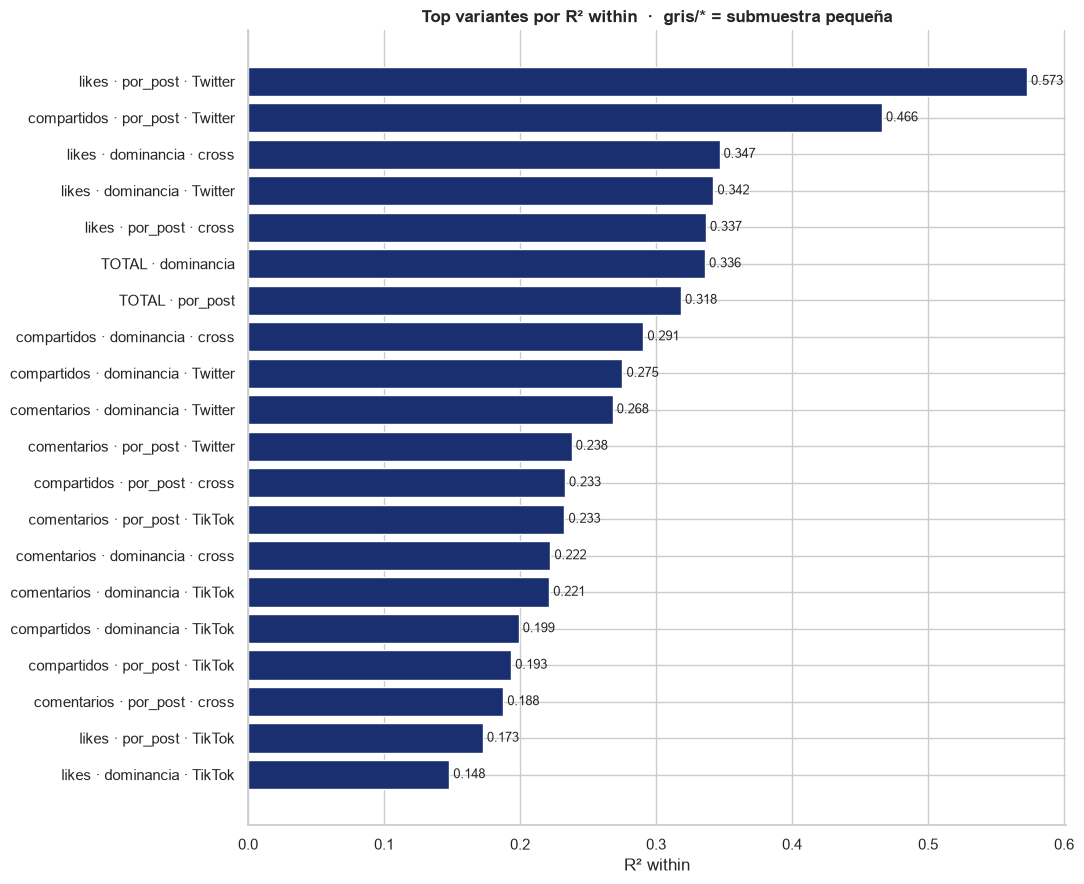

In [19]:
# --- Top variantes por R²_within (gris = submuestra pequeña) ---
plot = df_motor.dropna(subset=["R2_within"]).sort_values("R2_within").tail(20)
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(plot["variante"], plot["R2_within"],
        color=[GRIS if p else AZUL_SABANA for p in plot["muestra_pequena"]], edgecolor="white")
for y, (val, peq) in enumerate(zip(plot["R2_within"], plot["muestra_pequena"])):
    ax.text(val + 0.003, y, f"{val:.3f}{'*' if peq else ''}", va="center", fontsize=9)
ax.set_xlabel("R² within"); ax.set_title("Top variantes por R² within  ·  gris/* = submuestra pequeña", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()


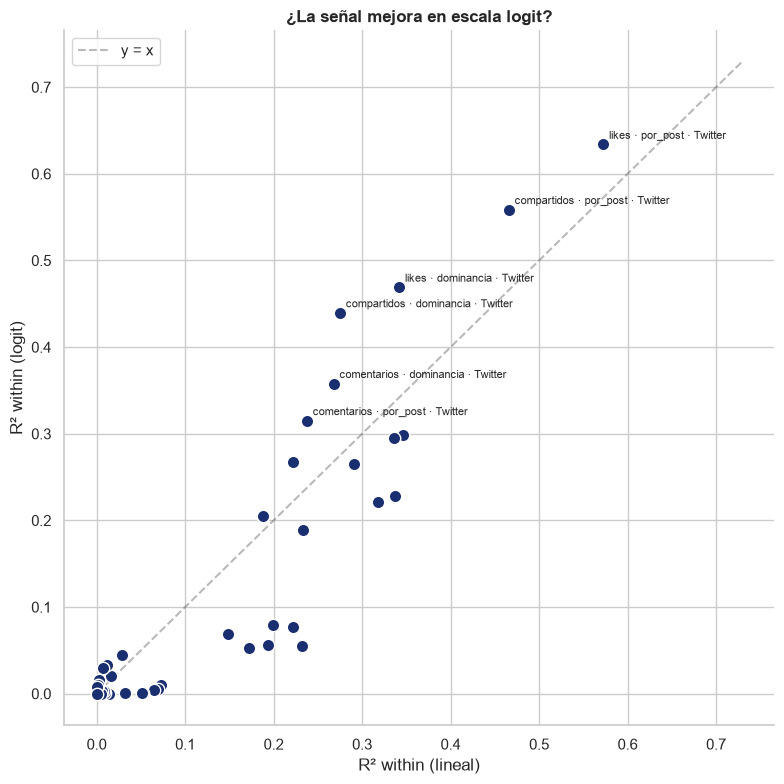

In [20]:
# --- Robustez lineal vs logit ---
valid = df_motor.dropna(subset=["R2_within", "R2_within_logit"])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(valid["R2_within"], valid["R2_within_logit"], s=80, color=AZUL_SABANA, edgecolor="white", zorder=5)
lim = max(valid["R2_within"].max(), valid["R2_within_logit"].max()) * 1.15
ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="y = x")
for _, r in valid.iterrows():
    if r["R2_within_logit"] - r["R2_within"] > 0.05:
        ax.annotate(r["variante"], (r["R2_within"], r["R2_within_logit"]), fontsize=8,
                    xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("R² within (lineal)"); ax.set_ylabel("R² within (logit)")
ax.set_title("¿La señal mejora en escala logit?", fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()


### Profundización: dispersión de las variables más predictivas

En vez de mirar la lente por-publicación en abstracto, graficamos directamente las **dispersiones
de las variantes con mayor R²_within**: cada punto es un candidato, el eje X su cuota de votos,
el eje Y su cuota en la métrica, y el color indica si ganó.

> La nube que se ve es la vista *pooled* (mezcla municipios); el R² anotado en cada título es el
> **within** (la señal honesta). Fíjate cómo las variantes de Twitter tienen R²_within alto pero
> pocos municipios (`n_munis` anotado), señal de submuestra sesgada.


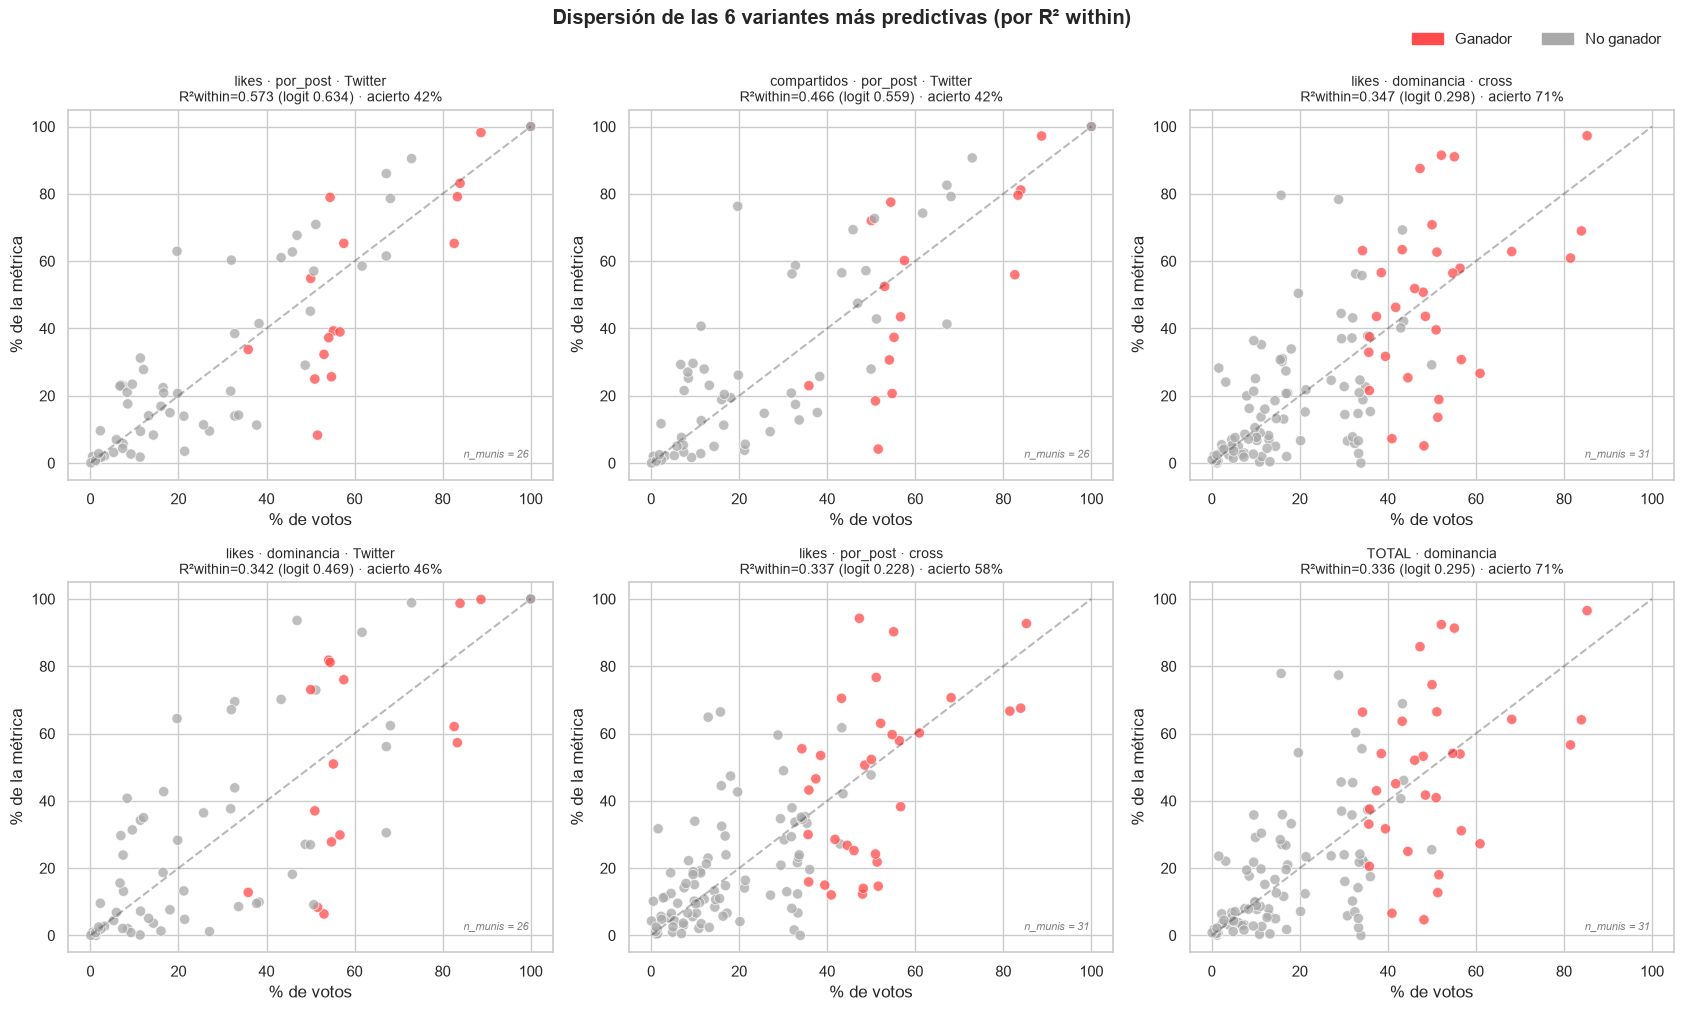

In [21]:
# --- Dispersión específica de las variantes con mayor R²_within ---
def args_variante(row):
    """Recupera (tipo, lente, plataforma) de una fila de df_motor."""
    plat = None if row["plataforma"] == "cross" else row["plataforma"]
    return row["tipo"], row["lente"], plat

top_n = 6
top_vars = df_motor.dropna(subset=["R2_within"]).head(top_n)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (_, row) in zip(axes.flatten(), top_vars.iterrows()):
    tipo, lente, plat = args_variante(row)
    d = prepare_lens_data(df_completo, tipo, lente, plat)
    sns.scatterplot(data=d, x="pct_votos", y="pct_metric", hue="Ganador",
                    palette={"Sí": ROJO, "No": GRIS}, alpha=0.75, s=55, ax=ax, legend=False)
    ax.plot([0, 100], [0, 100], "k--", alpha=0.3)
    ax.set_title(f"{row['variante']}\n"
                 f"R²within={row['R2_within']:.3f} (logit {row['R2_within_logit']:.3f}) · "
                 f"acierto {row['acierto_%']:.0f}%",
                 fontsize=10)
    ax.set_xlabel("% de votos"); ax.set_ylabel("% de la métrica")
    ax.text(0.95, 0.06, f"n_munis = {row['n_munis']}", transform=ax.transAxes,
            ha="right", fontsize=8, style="italic", color="gray")
# leyenda única
fig.legend(handles=[Patch(color=ROJO, label="Ganador"), Patch(color=GRIS, label="No ganador")],
           loc="upper right", bbox_to_anchor=(0.99, 1.0), ncol=2, frameon=False)
fig.suptitle(f"Dispersión de las {top_n} variantes más predictivas (por R² within)",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


> **Cierre Acto 4.** La tabla ordenada por `R²_within` —con robustez logit y acierto vs azar—
> es el criterio de selección. La lente *por publicación* mejora la señal respecto a totales, y
> Twitter destaca en gradiente (con la advertencia de submuestra).

---
# Puente al modelo (fase siguiente)

- **Objetivo:** cuota de voto dentro del campo competitivo, en **escala logit** (logit fraccional / beta).
- **Núcleo agnóstico:** features digitales seleccionadas (Acto 4) + nº de candidatos.
  Es lo que se corre el día antes de la **presidencial 2026** (validación out-of-sample real).
- **Controles del territorio:** se incorporan en la fase de modelado (no acá), separando núcleo
  universal de capa Colombia (DNP, MOE).
- **Selección final:** dado el n pequeño, parsimonia. Un AutoML acotado puede explorar
  combinaciones de las variables ya marcadas, **validando agrupado por contienda** (no por filas).
